Importing the dataset

In [1]:
import pandas as pd

food = pd.read_csv("food.csv")
food_nutrient = pd.read_csv("food_nutrient.csv")
nutrient = pd.read_csv("nutrient.csv")

food.head()


/var/folders/gc/jg64c1xs2nd2pvvqn3hy34lc0000gn/T/ipykernel_3406/763829690.py:4: DtypeWarning: Columns (0: footnote) have mixed types. Specify dtype option on import or set low_memory=False.
  food_nutrient = pd.read_csv("food_nutrient.csv")


,fdc_id,data_type,description,food_category_id,publication_date
0,319874,sample_food,"HUMMUS, SABRA CLASSIC",16.0,2019-04-01
1,319875,market_acquisition,"HUMMUS, SABRA CLASSIC",16.0,2019-04-01
2,319876,market_acquisition,"HUMMUS, SABRA CLASSIC",16.0,2019-04-01
3,319877,sub_sample_food,Hummus,16.0,2019-04-01
4,319878,sub_sample_food,Hummus,16.0,2019-04-01


Just keeping raw ingredients and removing store bought packaged foods for more accuracy

In [2]:
food_filtered = food[
    food["description"].str.contains(
        "raw|fresh|oil|flour|cheese|milk|egg|tomato|onion|garlic",
        case=False,
        na=False
    )
]


In [3]:
food_filtered["description"].sample(20)


65426               Khorasan, grain, wheat berry, dry, raw
67615    Corn, sweet, yellow and white kernels, husked,...
53127      Beef, ground, grass-fed, 90% lean, 10% fat, raw
30552                                       TOMATOES, ROMA
24496                                          OIL, PEANUT
66778                                   Arugula, baby, raw
12575                          Haddock, raw (CT) - CY060QU
66701                 Kiwifruit (kiwi), green, peeled, raw
4699     Peaches, Raw, Pass 2, Region 3, n/a, Yes, Ribo...
73898             Squash, pie pumpkin, peeled, seeded, raw
66889                   Asparagus, green, whole spear, raw
52962      Beef, ground, grass-fed, 90% lean, 10% fat, raw
74118                            Tomatillos, dehusked, raw
74884                 Watermelon, seedless, rind only, raw
21613        ALMOND MILK, UNSWEETENED, PLAIN, SHELF STABLE
44917                            Lettuce, leaf, green, raw
75499                       Peppers, jalapeno, seeded, r

Building ingredient table list 

In [4]:
# STEP B: Build ingredient lookup table from USDA FDC Foundation Foods
# Produces: ingredient_lookup.csv with fdc_id -> canonical ingredient
# Also includes the original FDC description for sanity checks.

import re
import pandas as pd

# -----------------------------
# 1) Load FDC files (Foundation Foods)
# -----------------------------
FOOD_CSV_PATH = "food.csv"  # adjust path if needed
food = pd.read_csv(FOOD_CSV_PATH)

# Safety: keep only columns we need (avoid huge memory use)
needed_cols = [c for c in ["fdc_id", "description", "data_type", "food_category_id"] if c in food.columns]
food = food[needed_cols].copy()

# -----------------------------
# 2) Quick filter to reduce obviously non-ingredient entries
#    (Foundation Foods is already ingredient-focused, but still has some prepared items)
# -----------------------------
# You can relax/tighten this later. For now: keep rows with a description.
food = food.dropna(subset=["description"]).copy()
food["description"] = food["description"].astype(str)

# Optional: if data_type exists, keep Foundation only
if "data_type" in food.columns:
    # Foundation foods dataset typically uses "foundation_food"
    food = food[food["data_type"].str.contains("foundation", case=False, na=False)].copy()

# -----------------------------
# 3) Canonical ingredient mapping (expandable)
#    Order matters: more specific patterns should go first.
# -----------------------------
PATTERN_TO_CANONICAL = [
    # Oils & fats
    (r"\bolive oil\b|\boil, olive\b", "olive_oil"),
    (r"\bcanola oil\b", "canola_oil"),
    (r"\bvegetable oil\b", "vegetable_oil"),
    (r"\bbutter\b", "butter"),

    # Core Italian vegetables
    (r"\btomato(es)?\b", "tomato"),
    (r"\bonion(s)?\b", "onion"),
    (r"\bgarlic\b", "garlic"),
    (r"\bbasil\b", "basil"),
    (r"\boregano\b", "oregano"),
    (r"\bparsley\b", "parsley"),
    (r"\brosemary\b", "rosemary"),
    (r"\bthyme\b", "thyme"),
    (r"\bspinach\b", "spinach"),
    (r"\bmushroom(s)?\b", "mushroom"),
    (r"\bzucchini\b", "zucchini"),
    (r"\beggplant\b|\baubergine\b", "eggplant"),
    (r"\bpepper\b", "pepper"),
    (r"\bbroccoli\b", "broccoli"),
    (r"\bkale\b", "kale"),

    # Fruits commonly used
    (r"\blemon\b", "lemon"),
    (r"\bbanana(s)?\b", "banana"),
    (r"\bblueberr(y|ies)\b", "blueberry"),
    (r"\bpeach(es)?\b", "peach"),
    (r"\bavocado\b", "avocado"),
    (r"\bapricot(s)?\b", "apricot"),
    (r"\bkiwi(fruit)?\b", "kiwi"),
    (r"\bcantaloupe\b|\bmelon\b", "melon"),

    # Beans & legumes
    (r"\bbeans?\b", "beans"),
    (r"\bkidney beans?\b", "kidney_beans"),
    (r"\bblack beans?\b", "black_beans"),
    (r"\bpinto beans?\b", "pinto_beans"),
    (r"\blentils?\b", "lentils"),
    (r"\bchickpeas?\b|\bgarbanzo\b", "chickpeas"),

    # Grains & pasta
    (r"\bpasta\b|\bspaghetti\b|\bpenne\b|\bfusilli\b|\bmacaroni\b", "pasta"),
    (r"\brace\b", "rice"),
    (r"\bflour\b", "flour"),

    # Dairy
    (r"\bparmesan\b|\bparmigiano\b", "parmesan_cheese"),
    (r"\bmozzarella\b", "mozzarella"),
    (r"\bricotta\b", "ricotta"),
    (r"\bpecorino\b", "pecorino"),
    (r"\bmilk\b", "milk"),
    (r"\byogurt\b", "yogurt"),

    # Protein sources
    (r"\begg(s)?\b", "egg"),
    (r"\bchicken\b", "chicken"),
    (r"\bbeef\b", "beef"),
    (r"\bpork\b", "pork"),
    (r"\bsalmon\b", "salmon"),
    (r"\btuna\b", "tuna"),
    (r"\bsnapper\b", "snapper"),
    (r"\bswordfish\b", "swordfish"),
    (r"\bbison\b", "bison"),

    # Nuts
    (r"\bpecans?\b", "pecans"),
    (r"\bpine nuts?\b", "pine_nuts"),
    (r"\bwalnuts?\b", "walnuts"),
    (r"\balmonds?\b", "almonds"),

    # Pantry basics
    (r"\bsalt\b", "salt"),
    (r"\bsugar(s)?\b", "sugar"),
]


# Precompile regexes for speed
COMPILED = [(re.compile(pat, flags=re.IGNORECASE), canon) for pat, canon in PATTERN_TO_CANONICAL]

def normalize_ingredient(desc: str) -> str | None:
    """Map an FDC description string to a canonical ingredient name."""
    if not isinstance(desc, str) or not desc.strip():
        return None

    d = desc.lower()

    for rx, canon in COMPILED:
        if rx.search(d):
            return canon

    return None  # unknown/unmapped

# -----------------------------
# 4) Apply mapping
# -----------------------------
food["ingredient"] = food["description"].apply(normalize_ingredient)

# Keep both mapped and unmapped so you can inspect what you're missing
mapped = food.dropna(subset=["ingredient"]).copy()
unmapped = food[food["ingredient"].isna()].copy()

# -----------------------------
# 5) Write outputs
# -----------------------------
# Main lookup (mapped only)
ingredient_lookup = mapped[["fdc_id", "ingredient", "description"]].drop_duplicates()
ingredient_lookup.to_csv("ingredient_lookup.csv", index=False)

# Helpful debug file: what didn't map
unmapped[["fdc_id", "description"]].drop_duplicates().to_csv("ingredient_unmapped_debug.csv", index=False)

# Summary print
print("✅ ingredient_lookup.csv saved")
print("Rows (mapped):", ingredient_lookup.shape[0])
print("Unique ingredients:", ingredient_lookup["ingredient"].nunique())
print("\nTop canonical ingredients:")
print(ingredient_lookup["ingredient"].value_counts().head(20))

print("\n✅ ingredient_unmapped_debug.csv saved")
print("Rows (unmapped):", unmapped.shape[0])


✅ ingredient_lookup.csv saved
Rows (mapped): 243
Unique ingredients: 42

Top canonical ingredients:
ingredient
beans        47
flour        30
beef         24
milk         18
mushroom     15
pork         13
tomato       10
egg           9
chicken       9
butter        6
onion         5
banana        5
spinach       4
salt          3
yogurt        3
sugar         3
olive_oil     3
broccoli      2
almonds       2
ricotta       2
Name: count, dtype: int64

✅ ingredient_unmapped_debug.csv saved
Rows (unmapped): 193


Attaching nutrient values to the ingredients

In [5]:
import pandas as pd

# -----------------------------
# Load files
# -----------------------------
ingredient_lookup = pd.read_csv("ingredient_lookup.csv")
food_nutrient = pd.read_csv("food_nutrient.csv")
nutrient = pd.read_csv("nutrient.csv")

# -----------------------------
# Keep nutrients we need
# -----------------------------
wanted_nutrients = {
    "Energy": "calories",
    "Protein": "protein",
    "Total lipid (fat)": "fat",
    "Carbohydrate, by difference": "carbs"
}

nutrient_subset = nutrient[
    nutrient["name"].isin(wanted_nutrients.keys())
][["id", "name"]]

nutrient_subset["nutrient_name"] = nutrient_subset["name"].map(
    wanted_nutrients
)

# -----------------------------
# Merge nutrient values
# -----------------------------
merged = food_nutrient.merge(
    nutrient_subset,
    left_on="nutrient_id",
    right_on="id"
)

merged = merged.merge(
    ingredient_lookup,
    on="fdc_id"
)

# -----------------------------
# Keep needed columns
# -----------------------------
ingredient_nutrients = merged[
    ["ingredient", "nutrient_name", "amount"]
]

# -----------------------------
# Aggregate per ingredient
# -----------------------------
ingredient_nutrients = (
    ingredient_nutrients
    .groupby(["ingredient", "nutrient_name"])
    ["amount"]
    .mean()
    .reset_index()
)

# -----------------------------
# Save table
# -----------------------------
ingredient_nutrients.to_csv(
    "ingredient_nutrient_table.csv",
    index=False
)

print("✅ Ingredient nutrient table created")
print(ingredient_nutrients.head())


✅ Ingredient nutrient table created
  ingredient nutrient_name      amount
0    almonds      calories  1605.00000
1    almonds         carbs    18.11731
2    almonds           fat    54.44500
3    almonds       protein    20.92519
4    apricot         carbs    10.23875


/var/folders/gc/jg64c1xs2nd2pvvqn3hy34lc0000gn/T/ipykernel_3406/2235284763.py:7: DtypeWarning: Columns (0: footnote) have mixed types. Specify dtype option on import or set low_memory=False.
  food_nutrient = pd.read_csv("food_nutrient.csv")


Actually creating the FOPCs

In [6]:
import pandas as pd
from pathlib import Path

INPUT_CSV = "ingredient_nutrient_table.csv"

OUT_DIR = Path(".")
ING_FACTS_PATH = OUT_DIR / "facts_ingredients.pl"
NUTR_FACTS_PATH = OUT_DIR / "facts_nutrients.pl"

def safe_atom(s: str) -> str:
    s = str(s).strip().lower()
    cleaned = []
    for ch in s:
        if ch.isalnum():
            cleaned.append(ch)
        else:
            cleaned.append("_")
    s = "".join(cleaned)

    while "__" in s:
        s = s.replace("__", "_")

    s = s.strip("_")
    if not s:
        return "unknown"
    if s[0].isdigit():
        s = "n_" + s
    return s

def format_float(x) -> str:
    try:
        fx = float(x)
    except Exception:
        return "0"
    return f"{fx:.6g}"

df = pd.read_csv(INPUT_CSV)

df["ingredient_atom"] = df["ingredient"].apply(safe_atom)
df["nutrient_atom"] = df["nutrient_name"].apply(safe_atom)

unique_ings = sorted(df["ingredient_atom"].unique())

with open(ING_FACTS_PATH, "w", encoding="utf-8") as f:
    f.write("% Ingredient facts\n")
    for ing in unique_ings:
        f.write(f"Ingredient({ing}).\n")

with open(NUTR_FACTS_PATH, "w", encoding="utf-8") as f:
    f.write("% Nutrient facts per 100g\n")
    for _, row in df.iterrows():
        ing = row["ingredient_atom"]
        nutr = row["nutrient_atom"]
        amt = format_float(row["amount"])
        f.write(f"HasNutrient({ing}, {nutr}).\n")
        f.write(f"NutrientValuePer100g({ing}, {nutr}, {amt}).\n")

print("Facts generated successfully!")


Facts generated successfully!


## Loading all ingredients (Data set and recipe ingredents)

**Allergen tagging (Top 9)**  
Run the cell below to build `facts_allergens.pl` from `all_ingredients_current.csv`. Only ingredients that contain any Top 9 allergen (milk, egg, fish, shellfish, tree nuts, peanut, wheat, soy, sesame) are tagged; the rest stay untagged. Load `facts_allergens.pl` in the next cell to query `HasAllergen(ingredient, allergen)` later.

In [7]:
# Generate facts_allergens.pl from all_ingredients_current.csv (Top 9 allergens only)
# Run this when the ingredient list changes. Then load facts_allergens.pl in the next cell.

import pandas as pd
import re

TOP9_ALLERGENS = {
    "milk": ["milk", "butter", "creme_fraiche", "fromage_frais", "mascarpone", "mozzarella",
             "parmesan_cheese", "parmigiano_reggiano", "pecorino", "ricotta", "yogurt"],
    "egg": ["egg", "egg_yolks"],
    "fish": ["anchovy", "salmon", "pilchards", "snapper", "swordfish", "tuna"],
    "shellfish": ["prawn", "shrimp", "crab", "lobster", "crayfish"],
    "tree_nuts": ["almonds", "pecans", "pine_nuts", "walnuts", "cashew", "hazelnut", "macadamia"],
    "peanut": ["peanut"],
    "wheat": ["flour", "bread", "pasta", "spaghetti", "penne", "rigatoni", "farfalle",
              "lasagna", "linguine", "paccheri", "bowtie"],
    "soy": ["soy_milk", "soy"],
    "sesame": ["sesame", "tahini"],
}

def normalize_ingredient_from_csv(s):
    """Extract ingredient atom from CSV value like \"('almonds',)\"."""
    s = str(s).strip().strip('"')
    m = re.search(r"['\"]([a-z0-9_]+)['\"]", s)
    return m.group(1) if m else s.replace("(", "").replace(")", "").replace("'", "").replace(",", "").strip()

def get_allergens_for_ingredient(ing: str):
    """Return list of (ingredient, allergen) for Top 9 only; empty if none."""
    ing_lower = ing.lower()
    out = []
    for allergen, keywords in TOP9_ALLERGENS.items():
        if any(kw in ing_lower for kw in keywords):
            out.append((ing, allergen))
    return out

# Load current ingredients
df = pd.read_csv("all_ingredients_current.csv")
ingredients = df["ingredient"].apply(normalize_ingredient_from_csv).dropna().unique().tolist()

# Build HasAllergen(ingredient, allergen). only for Top 9
lines = [
    "% ALLERGEN FACTS (Top 9). Only tagged ingredients; rest untagged.",
    "% HasAllergen(ingredient, allergen).",
    "%"
]
tagged = set()
for ing in sorted(ingredients):
    for ing_atom, allergen in get_allergens_for_ingredient(ing):
        lines.append(f"HasAllergen({ing_atom}, {allergen}).")
        tagged.add(ing_atom)

with open("facts_allergens.pl", "w", encoding="utf-8") as f:
    f.write("\n".join(lines) + "\n")

print(f"facts_allergens.pl written. Tagged {len(tagged)} ingredients with Top 9 allergens.")
print("Untagged (no Top 9):", len(ingredients) - len(tagged), "ingredients.")

facts_allergens.pl written. Tagged 56 ingredients with Top 9 allergens.
Untagged (no Top 9): 126 ingredients.


In [8]:
!pip install pyDatalog

  Using cached pyDatalog-0.17.4.tar.gz (325 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pyDatalog: filename=pydatalog-0.17.4-py2.py3-none-any.whl size=74280 sha256=ccfa82fbcc5b09eb95b18ef9dc46ea840ad03b8d5d639ff60075bb342b5d2101
  Stored in directory: /Users/shi1gesong/Library/Caches/pip/wheels/d7/74/40/67de2bdb16dbcaded57dd1dafa7d3634537c114ca4465b92f7
Successfully built pyDatalog

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [9]:
from pyDatalog import pyDatalog
import re

pyDatalog.clear()

# Declare terms you’ll use
pyDatalog.create_terms("""
    Ingredient, HasNutrient, NutrientValuePer100g,
    IngredientAlias, CanonicalIngredient, IgnoredIngredient,
    HasNutrientResolved, ResolvedNutrientValuePer100g,
    HasAllergen,
    I, C, N, V
""")

def load_prolog_style_facts(file_path: str):
    """
    Loads facts written like:
      Predicate(arg1, arg2, ...).
    where args are atoms (strings without quotes) or numbers.
    Supports any predicate name.
    """
    fact_re = re.compile(r"([A-Za-z_]\w*)\(([^)]+)\)\.?")

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("%"):
                continue
            for m in fact_re.finditer(line):
                pred = m.group(1)
                args_str = m.group(2).strip()

            # Split by commas (your facts don’t contain quoted strings, so safe)
                raw_args = [a.strip() for a in args_str.split(",") if a.strip()]
                args = []
                for a in raw_args:
                    try:
                        args.append(float(a))
                    except ValueError:
                        args.append(a)

                
                if pred not in globals():
                    continue

                predicate_obj = globals()[pred]
                +predicate_obj(*args)

# Load your files
load_prolog_style_facts("facts_ingredients.pl")
load_prolog_style_facts("facts_nutrients.pl")
load_prolog_style_facts("facts_standardized_overrides.pl")
load_prolog_style_facts("facts_allergens.pl")

# Alias-resolution rules
ResolvedNutrientValuePer100g(I, N, V) <= NutrientValuePer100g(I, N, V)
ResolvedNutrientValuePer100g(I, N, V) <= IngredientAlias(I, C) & NutrientValuePer100g(C, N, V)

HasNutrientResolved(I, N) <= HasNutrient(I, N)
HasNutrientResolved(I, N) <= IngredientAlias(I, C) & HasNutrient(C, N)

print("✅ Loaded facts (Prolog-style) + enabled alias resolution + allergens.")

✅ Loaded facts (Prolog-style) + enabled alias resolution + allergens.


** Example output:** See the **final block at the end of the notebook** for a printed example of several ingredients with their tags (alias/base), nutritional values per 100g, and allergens.

In [10]:
import pandas as pd
import re

# ---- Paths (edit if needed) ----
ING_LOOKUP_PATH = "ingredient_lookup.csv"
OUT_SELECTED_PATH = "ingredient_lookup_selected.csv"

df = pd.read_csv(ING_LOOKUP_PATH)

NEGATIVE_TERMS = [
    "canned", "cooked", "fried", "roasted", "grilled", "baked",
    "frozen", "prepared", "with", "added", "sweetened", "in sauce",
    "pickled", "smoked", "breaded", "seasoned", "dried", "dehydrated"
]

POSITIVE_TERMS = [
    "raw", "fresh"
]

# Optional ingredient-specific boosts (helps pick a more “standard” entry)
PREFERRED_REGEX = {
    "tomato": [r"tomatoes, red, ripe, raw", r"tomato.*raw"],
    "onion":  [r"onions?, raw"],
    "garlic": [r"garlic.*raw"],
    "olive_oil": [r"oil, olive(,|$)"],
}

def score_description(ingredient: str, desc: str) -> float:
    d = str(desc).lower()
    score = 0.0

    # Positive boosts
    for t in POSITIVE_TERMS:
        if t in d:
            score += 5.0 if t == "raw" else 2.0

    # Negative penalties
    for t in NEGATIVE_TERMS:
        if t in d:
            score -= 4.0

    # Ingredient-specific preferences
    if ingredient in PREFERRED_REGEX:
        for rx in PREFERRED_REGEX[ingredient]:
            if re.search(rx, d):
                score += 10.0

    # Tie-breaker: shorter descriptions usually more “basic”
    score += max(0, 3.0 - (len(d) / 80.0))  # small bonus for shorter

    return score

df["score"] = df.apply(lambda r: score_description(r["ingredient"], r["description"]), axis=1)

# Pick best row per canonical ingredient
selected = (
    df.sort_values(["ingredient", "score"], ascending=[True, False])
      .groupby("ingredient", as_index=False)
      .head(1)
      .reset_index(drop=True)
)

selected.to_csv(OUT_SELECTED_PATH, index=False)

print("✅ Saved:", OUT_SELECTED_PATH)
print("Unique ingredients:", selected["ingredient"].nunique())
print("\nSample selections:")
print(selected[["ingredient", "fdc_id", "description", "score"]].head(15))


✅ Saved: ingredient_lookup_selected.csv
Unique ingredients: 42

Sample selections:
   ingredient   fdc_id                                        description  \
0     almonds  2346393                          Nuts, almonds, whole, raw   
1     apricot  2710815                            Apricot, with skin, raw   
2     avocado  2710824                         Avocado, Hass, peeled, raw   
3      banana   790774                             Bananas, overripe, raw   
4       beans  2346400                            Beans, snap, green, raw   
5        beef  2727573                        Beef, tenderloin steak, raw   
6       bison  2727571                                 Bison, ground, raw   
7   blueberry  2263889                                   Blueberries, raw   
8    broccoli   321900                                      Broccoli, raw   
9      butter   790508                              Butter, stick, salted   
10    chicken  2727568                  Chicken, wing, meat and skin, 

In [11]:
def print_fopc_examples(file_path, n=15):
    print(f"\n--- Sample facts from {file_path} ---\n")
    
    with open(file_path, "r", encoding="utf-8") as f:
        count = 0
        for line in f:
            if line.startswith("%"):
                    continue
            print(line.strip())
            count += 1
            if count >= n:
                break

print_fopc_examples("facts_ingredients.pl", 20)
print_fopc_examples("facts_nutrients.pl", 20)



--- Sample facts from facts_ingredients.pl ---

Ingredient(almonds).
Ingredient(apricot).
Ingredient(avocado).
Ingredient(banana).
Ingredient(beans).
Ingredient(beef).
Ingredient(bison).
Ingredient(blueberry).
Ingredient(broccoli).
Ingredient(butter).
Ingredient(chicken).
Ingredient(egg).
Ingredient(eggplant).
Ingredient(flour).
Ingredient(garlic).
Ingredient(kale).
Ingredient(kiwi).
Ingredient(lentils).
Ingredient(melon).
Ingredient(milk).

--- Sample facts from facts_nutrients.pl ---

HasNutrient(almonds, calories).
NutrientValuePer100g(almonds, calories, 1605).
HasNutrient(almonds, carbs).
NutrientValuePer100g(almonds, carbs, 18.1173).
HasNutrient(almonds, fat).
NutrientValuePer100g(almonds, fat, 54.445).
HasNutrient(almonds, protein).
NutrientValuePer100g(almonds, protein, 20.9252).
HasNutrient(apricot, carbs).
NutrientValuePer100g(apricot, carbs, 10.2387).
HasNutrient(apricot, fat).
NutrientValuePer100g(apricot, fat, 0.405).
HasNutrient(apricot, protein).
NutrientValuePer100g(apr

## Adding the alergens

In [12]:
from pyDatalog import pyDatalog

# Declare allergen predicates
pyDatalog.create_terms("""
    ContainsAllergen, ContainsAllergenResolved,
    Allergen,
    A
""")

# List top 9 allergens (as atoms)
TOP9 = [
    "milk", "egg", "fish", "crustacean_shellfish",
    "tree_nuts", "peanuts", "wheat", "soybeans", "sesame"
]

# Add simple facts that these are allergens (optional, but nice)
for a in TOP9:
    +Allergen(a)

# IMPORTANT: Resolve allergens through aliases (same idea as nutrients)
# If an ingredient is an alias of a canonical ingredient, it inherits allergens too.
ContainsAllergenResolved(I, A) <= ContainsAllergen(I, A)
ContainsAllergenResolved(I, A) <= IngredientAlias(I, C) & ContainsAllergen(C, A)

print("✅ Allergen predicates ready (top 9) + alias resolution enabled.")

✅ Allergen predicates ready (top 9) + alias resolution enabled.


In [13]:
# Helper: add multiple allergen facts quickly
def add_allergens(ingredient, allergens):
    for a in allergens:
        +ContainsAllergen(ingredient, a)

# -----------------------
# DAIRY (milk)
# -----------------------
dairy_items = [
    "parmigiano_reggiano", "pecorino", "pecorino_cheese",
    "mascarpone", "mozzarella_balls", "creme_fraiche", "fromage_frais",
    #"vegan_butter"  # NOTE: vegan butter *usually* has no milk, but some do; assume NO milk unless you want strict warnings.
]

# If you want vegan_butter to be treated as dairy-free, comment it out above.
for ing in dairy_items:
    if ing != "vegan_butter":  # assume dairy-free for vegan butter
        add_allergens(ing, ["milk"])

# soy milk
add_allergens("soy_milk", ["soybeans"])

# -----------------------
# EGGS
# -----------------------
add_allergens("egg_yolks", ["egg"])

# -----------------------
# WHEAT (gluten proxy via wheat)
# -----------------------
wheat_items = [
    "spaghetti", "penne", "rigatoni", "paccheri_pasta", "linguine_pasta",
    "farfalle", "bowtie_pasta", "lasagna_noodles",
    "bread", "wholegrain_bread"
]
for ing in wheat_items:
    add_allergens(ing, ["wheat"])

# -----------------------
# FISH
# -----------------------
fish_items = ["anchovy_fillet", "pilchards"]
for ing in fish_items:
    add_allergens(ing, ["fish"])

# -----------------------
# CRUSTACEAN SHELLFISH
# -----------------------
add_allergens("king_prawns", ["crustacean_shellfish"])

# -----------------------
# Condiments & others (usually none of top9 by default)
# Worcestershire sauce can contain anchovy in some brands → fish
# If you want strict safety: tag as fish.
add_allergens("worcestershire_sauce", ["fish"])

print("✅ Added allergen facts for known items.")

✅ Added allergen facts for known items.


In [14]:
# Gather all known ingredients
all_ing_query = Ingredient(I)
all_ingredients = sorted(list(all_ing_query.data))

print("Total Ingredient(...) facts:", len(all_ingredients))
print("\nFirst 60 ingredients:")
print(all_ingredients[:60])

print(Ingredient(I))

Total Ingredient(...) facts: 182

First 60 ingredients:
[('almonds',), ('anchovy_fillet',), ('anchovy_fillet_std',), ('apricot',), ('asparagus',), ('asparagus_std',), ('avocado',), ('baby_plum_tomatoes',), ('bacon',), ('bacon_std',), ('banana',), ('basil',), ('bay_leaves',), ('beans',), ('beef',), ('beef_stock',), ('beef_stock_std',), ('bison',), ('black_olives',), ('black_pepper',), ('blueberry',), ('bowtie_pasta',), ('bread',), ('bread_white_std',), ('broccoli',), ('butter',), ('cannellini_beans',), ('cannellini_beans_std',), ('carrots',), ('carrots_std',), ('caster_sugar',), ('celery',), ('celery_std',), ('cherry_tomatoes',), ('chicken',), ('chicken_breasts',), ('chicken_breasts_std',), ('chicken_stock',), ('chicken_stock_cube',), ('chicken_stock_cube_std',), ('chicken_stock_std',), ('chopped_tomatoes',), ('citrus_std',), ('creme_fraiche',), ('creme_fraiche_std',), ('dark_rum',), ('dark_rum_std',), ('dry_pasta',), ('dry_white_wine',), ('egg',), ('egg_yolks',), ('egg_yolks_std',), ('

In [15]:
#saving all ingredients
import pandas as pd
pd.DataFrame({"ingredient": all_ingredients}).to_csv("all_ingredients_current.csv", index=False)
print("✅ Saved all_ingredients_current.csv")

✅ Saved all_ingredients_current.csv


In [16]:
# =============================================================================
# EXAMPLE BLOCK: Sample ingredients with tags, nutrition (per 100g), and allergens
# Run after loading all fact files. Output appears in this block.
# =============================================================================

from pyDatalog import pyDatalog

def first_values(answers):
    if not answers or answers in (True, None):
        return []
    return [t[0] if isinstance(t, (list, tuple)) and len(t) >= 1 else t for t in (answers if isinstance(answers, list) else [answers])]

EXAMPLES = ["almonds", "spaghetti", "milk", "salmon", "tomato", "egg", "flour"]

print("=" * 70)
print("EXAMPLE: Ingredients with tags, nutrition (per 100g), and allergens")
print("=" * 70)

for ing in EXAMPLES:
    print(f"\n--- {ing} ---")
    try:
        r = pyDatalog.ask(f"IngredientAlias('{ing}', C)")
        vals = first_values(r.answers if r else None)
        if vals:
            print(f"  Tag: alias -> canonical = {vals}")
        else:
            print(f"  Tag: base ingredient")
    except Exception:
        print(f"  Tag: base ingredient")

    print("  Nutrition (per 100g):")
    for nut in ["calories", "protein", "fat", "carbs"]:
        try:
            r = pyDatalog.ask(f"ResolvedNutrientValuePer100g('{ing}', '{nut}', V)")
            vals = first_values(r.answers if r else None)
            if vals:
                print(f"    {nut}: {vals[0]}")
        except Exception:
            pass

    try:
        r = pyDatalog.ask(f"HasAllergen('{ing}', A)")
        vals = first_values(r.answers if r else None)
        print(f"  Allergens: {vals if vals else '(none / untagged)'}")
    except Exception:
        print(f"  Allergens: (none / untagged)")

print("\n" + "=" * 70)

EXAMPLE: Ingredients with tags, nutrition (per 100g), and allergens

--- almonds ---
  Tag: base ingredient
  Nutrition (per 100g):
    calories: 1605.0
    protein: 20.9252
    fat: 54.445
    carbs: 18.1173
  Allergens: ['tree_nuts']

--- spaghetti ---
  Tag: alias -> canonical = ['dry_pasta']
  Nutrition (per 100g):
    calories: 371.0
    protein: 13.0
    fat: 1.5
    carbs: 75.0
  Allergens: ['wheat']

--- milk ---
  Tag: base ingredient
  Nutrition (per 100g):
    calories: 121.25
    protein: 3.97911
    fat: 2.95411
    carbs: 3.73499
  Allergens: ['milk']

--- salmon ---
  Tag: base ingredient
  Nutrition (per 100g):
    protein: 21.3094
    fat: 9.023
    carbs: 0.0
  Allergens: ['fish']

--- tomato ---
  Tag: base ingredient
  Nutrition (per 100g):
    calories: 58.5
    protein: 1.339
    fat: 0.42513
    carbs: 6.68066
  Allergens: (none / untagged)

--- egg ---
  Tag: base ingredient
  Nutrition (per 100g):
    calories: 759.556
    protein: 26.6111
    fat: 18.9189
    

In [17]:
def show_ingredient_allergens(ingredient):
    res = ContainsAllergenResolved(ingredient, A)
    allergens = sorted(list(res.data)) if hasattr(res, "data") else []
    return allergens

demo_examples = [
    "spaghetti",
    "pecorino_cheese",
    "soy_milk",
    "egg_yolks",
    "king_prawns",
    "worcestershire_sauce",
    "tomatoes",
    "olive_oil"  # likely no allergens in our map
]

for ing in demo_examples:
    print(f"{ing:22s} -> {show_ingredient_allergens(ing)}")

spaghetti              -> [('wheat',)]
pecorino_cheese        -> [('milk',)]
soy_milk               -> [('soybeans',)]
egg_yolks              -> [('egg',)]
king_prawns            -> [('crustacean_shellfish',)]
worcestershire_sauce   -> [('fish',)]
tomatoes               -> []
olive_oil              -> []


# Recipe FOPC

In [18]:
pyDatalog.create_terms("X,Y,Z")
print(NutrientValuePer100g(X,'protein', Y) & (Y>20))

X                       | Y      
------------------------|--------
king_prawns_std         | 24.0   
veal_std                | 24.0   
pilchards_std           | 24.0   
parmesan_cheese         | 29.8696
snapper                 | 20.6625
egg                     | 26.6111
salmon                  | 21.3094
almonds                 | 20.9252
salt                    | 21.0   
beef                    | 21.3471
olive_oil               | 26.9375
pecorino_std            | 28.0   
parmigiano_reggiano_std | 38.0   
tuna                    | 21.85  
butter                  | 21.746 
mozzarella_balls_std    | 28.0   
minced_beef_std         | 26.0   
chicken_breasts_std     | 31.0   
lentils                 | 23.5688
anchovy_fillet_std      | 29.0   
yeast_std               | 40.0   
mozzarella              | 23.7   
bacon_std               | 37.0   
chicken                 | 21.1472


In [19]:
# Adding Recipes logic
pyDatalog.create_terms(
    'Recipe, Uses, UnitToMl, UnitToGram'
)
+UnitToMl('tsp', 4.92892)
+UnitToMl('tbsp', 14.7868)
+UnitToGram('lb', 453.592)

In [20]:
pyDatalog.create_terms('RecipeHasNutrient, R, I, V, N')

RecipeHasNutrient(R, N) <= (
    Uses(R, I) &
    NutrientValuePer100g(I, N, V) &
    (V > 0)
)

RecipeHasNutrient(R,N) <= Uses(R,I)&NutrientValueP

In [21]:
Ingredient(X)

[('lime',), ('lemon',), ('citrus_std',), ('yeast',), ('yeast_std',), ('water',), ('red_chili_flake',), ('red_chilli_flakes',), ('red_chilli_flake',), ('lemon_zest',), ('orange_zest',), ('smoky_paprika',), ('fennel_seeds',), ('italian_seasoning',), ('black_pepper',), ('nutmeg',), ('bay_leaves',), ('sage',), ('rosemary',), ('marjoram',), ('parsley',), ('thyme',), ('basil',), ('oregano',), ('ignored_seasoning_std',), ('dark_rum',), ('red_wine',), ('dry_white_wine',), ('white_wine',), ('egg_yolks',), ('garlic_clove',), ('black_olives',), ('green_olives',), ('honey',), ('icing_sugar',), ('caster_sugar',), ('wholegrain_bread',), ('bread',), ('rice',), ('cannellini_beans',), ('red_onions',), ('onions',), ('sugar_snap_peas',), ('snap_peas',), ('fennel',), ('fennel_bulb',), ('asparagus',), ('lettuce',), ('potatoes',), ('mushrooms',), ('celery',), ('carrots',), ('pilchards',), ('king_prawns',), ('anchovy_fillet',), ('italian_fennel_sausages',), ('chicken_breasts',), ('bacon',), ('veal',), ('minc

In [22]:
+Recipe("spicy_arrabiata_penne")
+Uses("spicy_arrabiata_penne", "penne")
+Uses("spicy_arrabiata_penne", "olive_oil")
+Uses("spicy_arrabiata_penne", "garlic")
+Uses("spicy_arrabiata_penne", "italian_seasoning")
+Uses("spicy_arrabiata_penne", "basil")
+Uses("spicy_arrabiata_penne", "parmigiano-reggiano")
+Uses("spicy_arrabiata_penne", "red_chilli_flake")

+Recipe('spaghetti_bolognese')
+Uses('spaghetti_bolognese','onion')
+Uses('spaghetti_bolognese','olive_oil')
+Uses('spaghetti_bolognese','garlic')
+Uses('spaghetti_bolognese','beef')
+Uses('spaghetti_bolognese','mushroom')
+Uses('spaghetti_bolognese','tomato')
+Uses('spaghetti_bolognese','beef_stock')
+Uses('spaghetti_bolognese','tomato_paste')
+Uses('spaghetti_bolognese','spaghetti')
+Uses('spaghetti_bolognese','parmesan_cheese')
+Uses('spaghetti_bolognese','worcestershire_sauce')

+Recipe("vegan_lasagna")
+Uses("vegan_lasagna", "lentils")
+Uses("vegan_lasagna", "carrots")
+Uses("vegan_lasagna", "onion")
+Uses("vegan_lasagna", "zucchini")
+Uses("vegan_lasagna", "coriander")
+Uses("vegan_lasagna", "spinach")
+Uses("vegan_lasagna", "lasagna_noodles")
+Uses("vegan_lasagna", "vegan_butter")
+Uses("vegan_lasagna", "flour")
+Uses("vegan_lasagna", "soy_milk")
+Uses("vegan_lasagna", "mustard")
+Uses("vegan_lasagna", "vinegar")

+Recipe("budino_di_ricotta")
+Uses("budino_di_ricotta", "ricotta")
+Uses("budino_di_ricotta", "eggs")
+Uses("budino_di_ricotta", "flour")
+Uses("budino_di_ricotta", "sugar")
+Uses("budino_di_ricotta", "cinnamon")
+Uses("budino_di_ricotta", "lemons")
+Uses("budino_di_ricotta", "dark_rum")
+Uses("budino_di_ricotta", "icing_sugar")

+Recipe("chicken_alfredo_primavera")
+Uses("chicken_alfredo_primavera", "butter")
+Uses("chicken_alfredo_primavera", "olive_oil")
+Uses("chicken_alfredo_primavera", "chicken")
+Uses("chicken_alfredo_primavera", "salt")
+Uses("chicken_alfredo_primavera", "squash")
+Uses("chicken_alfredo_primavera", "broccoli")
+Uses("chicken_alfredo_primavera", "mushrooms")
+Uses("chicken_alfredo_primavera", "pepper")
+Uses("chicken_alfredo_primavera", "onion")
+Uses("chicken_alfredo_primavera", "garlic")
+Uses("chicken_alfredo_primavera", "red_chilli_flakes")
+Uses("chicken_alfredo_primavera", "white_wine")
+Uses("chicken_alfredo_primavera", "milk")
+Uses("chicken_alfredo_primavera", "heavy_cream")
+Uses("chicken_alfredo_primavera", "parmesan_cheese")
+Uses("chicken_alfredo_primavera", "bowtie_pasta")
+Uses("chicken_alfredo_primavera", "salt")
+Uses("chicken_alfredo_primavera", "pepper")
+Uses("chicken_alfredo_primavera", "parsley")

+Recipe("chilli_prawn_linguine")
+Uses("chilli_prawn_linguine", "linguine_pasta")
+Uses("chilli_prawn_linguine", "sugar_snap_peas")
+Uses("chilli_prawn_linguine", "olive_oil")
+Uses("chilli_prawn_linguine", "garlic_clove")
+Uses("chilli_prawn_linguine", "red_chilli_flake")
+Uses("chilli_prawn_linguine", "king_prawns")
+Uses("chilli_prawn_linguine", "cherry_tomatoes")
+Uses("chilli_prawn_linguine", "basil")
+Uses("chilli_prawn_linguine", "lettuce")
+Uses("chilli_prawn_linguine", "bread")
+Uses("chilli_prawn_linguine", "fromage_frais")
+Uses("chilli_prawn_linguine", "lime")
+Uses("chilli_prawn_linguine", "caster_sugar")

+Recipe("fettuccine_alfredo")
+Uses("fettuccine_alfredo", "fettuccine")
+Uses("fettuccine_alfredo", "heavy_cream")
+Uses("fettuccine_alfredo", "butter")
+Uses("fettuccine_alfredo", "parmesan")
+Uses("fettuccine_alfredo", "parsley")
+Uses("fettuccine_alfredo", "black_pepper")

+Recipe("lasagne")
+Uses("lasagne", "olive_oil")
+Uses("lasagne", "bacon")
+Uses("lasagne", "onion")
+Uses("lasagne", "celery")
+Uses("lasagne", "carrots")
+Uses("lasagne", "garlic")
+Uses("lasagne", "minced_beef")
+Uses("lasagne", "tomato_puree")
+Uses("lasagne", "chopped_tomatoes")
+Uses("lasagne", "honey")
+Uses("lasagne", "lasagna_noodles")
+Uses("lasagne", "creme_fraiche")
+Uses("lasagne", "mozzarella_balls")
+Uses("lasagne", "parmesan_cheese")
+Uses("lasagne", "basil")

+Recipe("mediterranean_pasta_salad")
+Uses("mediterranean_pasta_salad", "mozzarella_balls")
+Uses("mediterranean_pasta_salad", "baby_plum_tomatoes")
+Uses("mediterranean_pasta_salad", "basil")
+Uses("mediterranean_pasta_salad", "farfalle")
+Uses("mediterranean_pasta_salad", "extra_virgin_olive_oil")
+Uses("mediterranean_pasta_salad", "green_olives")
+Uses("mediterranean_pasta_salad", "tuna")
+Uses("mediterranean_pasta_salad", "salt")
+Uses("mediterranean_pasta_salad", "pepper")

+Recipe("osso_buco_alla_milanese")
+Uses("osso_buco_alla_milanese", "veal")
+Uses("osso_buco_alla_milanese", "flour")
+Uses("osso_buco_alla_milanese", "olive_oil")
+Uses("osso_buco_alla_milanese", "butter")
+Uses("osso_buco_alla_milanese", "onion")
+Uses("osso_buco_alla_milanese", "carrots")
+Uses("osso_buco_alla_milanese", "celery")
+Uses("osso_buco_alla_milanese", "fennel")
+Uses("osso_buco_alla_milanese", "garlic")
+Uses("osso_buco_alla_milanese", "orange_zest")
+Uses("osso_buco_alla_milanese", "marjoram")
+Uses("osso_buco_alla_milanese", "bay_leaves")
+Uses("osso_buco_alla_milanese", "dry_white_wine")
+Uses("osso_buco_alla_milanese", "chicken_stock")
+Uses("osso_buco_alla_milanese", "tomatoes")
+Uses("osso_buco_alla_milanese", "parsley")
+Uses("osso_buco_alla_milanese", "garlic")
+Uses("osso_buco_alla_milanese", "lemon_zest")

+Recipe("pilchard_puttanesca")
+Uses("pilchard_puttanesca", "spaghetti")
+Uses("pilchard_puttanesca", "olive_oil")
+Uses("pilchard_puttanesca", "onion")
+Uses("pilchard_puttanesca", "garlic")
+Uses("pilchard_puttanesca", "red_chilli")
+Uses("pilchard_puttanesca", "tomato_puree")
+Uses("pilchard_puttanesca", "pilchards")
+Uses("pilchard_puttanesca", "black_olives")
+Uses("pilchard_puttanesca", "parmesan")

+Recipe("pizza_express_margherita")
+Uses("pizza_express_margherita", "water")
+Uses("pizza_express_margherita", "sugar")
+Uses("pizza_express_margherita", "yeast")
+Uses("pizza_express_margherita", "flour")
+Uses("pizza_express_margherita", "salt")
+Uses("pizza_express_margherita", "olive_oil")
+Uses("pizza_express_margherita", "passata")
+Uses("pizza_express_margherita", "mozzarella")
+Uses("pizza_express_margherita", "oregano")
+Uses("pizza_express_margherita", "basil")
+Uses("pizza_express_margherita", "black_pepper")

+Recipe("potato_gratin_with_chicken")
+Uses("potato_gratin_with_chicken", "potatoes")
+Uses("potato_gratin_with_chicken", "onions")
+Uses("potato_gratin_with_chicken", "olive_oil")
+Uses("potato_gratin_with_chicken", "chicken_stock")
+Uses("potato_gratin_with_chicken", "creme_fraiche")
+Uses("potato_gratin_with_chicken", "parmesan")
+Uses("potato_gratin_with_chicken", "chicken_breasts")
+Uses("potato_gratin_with_chicken", "bacon")
+Uses("potato_gratin_with_chicken", "spinach")
+Uses("potato_gratin_with_chicken", "peas")

+Recipe("ribollita")
+Uses("ribollita", "olive_oil")
+Uses("ribollita", "onion")
+Uses("ribollita", "carrots")
+Uses("ribollita", "celery")
+Uses("ribollita", "garlic")
+Uses("ribollita", "cannellini_beans")
+Uses("ribollita", "canned_tomatoes")
+Uses("ribollita", "water")
+Uses("ribollita", "rosemary")
+Uses("ribollita", "thyme")
+Uses("ribollita", "kale")
+Uses("ribollita", "wholegrain_bread")
+Uses("ribollita", "red_onions")
+Uses("ribollita", "parmesan")

+Recipe("rigatoni_with_fennel_sausage_sauce")
+Uses("rigatoni_with_fennel_sausage_sauce", "olive_oil")
+Uses("rigatoni_with_fennel_sausage_sauce", "italian_fennel_sausages")
+Uses("rigatoni_with_fennel_sausage_sauce", "onion")
+Uses("rigatoni_with_fennel_sausage_sauce", "fennel_bulb")
+Uses("rigatoni_with_fennel_sausage_sauce", "smoky_paprika")
+Uses("rigatoni_with_fennel_sausage_sauce", "garlic")
+Uses("rigatoni_with_fennel_sausage_sauce", "fennel_seeds")
+Uses("rigatoni_with_fennel_sausage_sauce", "red_wine")
+Uses("rigatoni_with_fennel_sausage_sauce", "chopped_tomatoes")
+Uses("rigatoni_with_fennel_sausage_sauce", "caster_sugar")
+Uses("rigatoni_with_fennel_sausage_sauce", "pitted_black_olives")
+Uses("rigatoni_with_fennel_sausage_sauce", "rigatoni")
+Uses("rigatoni_with_fennel_sausage_sauce", "pecorino")
+Uses("rigatoni_with_fennel_sausage_sauce", "anchovy_fillet")
+Uses("rigatoni_with_fennel_sausage_sauce", "garlic")
+Uses("rigatoni_with_fennel_sausage_sauce", "olive_oil")
+Uses("rigatoni_with_fennel_sausage_sauce", "basil")

+Recipe("salmon_prawn_risotto")
+Uses("salmon_prawn_risotto", "butter")
+Uses("salmon_prawn_risotto", "onion")
+Uses("salmon_prawn_risotto", "rice")
+Uses("salmon_prawn_risotto", "white_wine")
+Uses("salmon_prawn_risotto", "vegetable_stock")
+Uses("salmon_prawn_risotto", "lemon")
+Uses("salmon_prawn_risotto", "king_prawns")
+Uses("salmon_prawn_risotto", "salmon")
+Uses("salmon_prawn_risotto", "asparagus")
+Uses("salmon_prawn_risotto", "black_pepper")
+Uses("salmon_prawn_risotto", "parmesan")

+Recipe("spaghetti_alla_carbonara")
+Uses("spaghetti_alla_carbonara", "spaghetti")
+Uses("spaghetti_alla_carbonara", "egg_yolks")
+Uses("spaghetti_alla_carbonara", "salt")
+Uses("spaghetti_alla_carbonara", "bacon")
+Uses("spaghetti_alla_carbonara", "pecorino")
+Uses("spaghetti_alla_carbonara", "black_pepper")

+Recipe("spinach_&_ricotta_cannelloni")
+Uses("spinach_&_ricotta_cannelloni", "olive_oil")
+Uses("spinach_&_ricotta_cannelloni", "garlic")
+Uses("spinach_&_ricotta_cannelloni", "caster_sugar")
+Uses("spinach_&_ricotta_cannelloni", "red_wine_vinegar")
+Uses("spinach_&_ricotta_cannelloni", "chopped_tomatoes")
+Uses("spinach_&_ricotta_cannelloni", "basil_leaves")
+Uses("spinach_&_ricotta_cannelloni", "mascarpone")
+Uses("spinach_&_ricotta_cannelloni", "milk")
+Uses("spinach_&_ricotta_cannelloni", "parmesan")
+Uses("spinach_&_ricotta_cannelloni", "mozzarella")
+Uses("spinach_&_ricotta_cannelloni", "spinach")
+Uses("spinach_&_ricotta_cannelloni", "parmesan")
+Uses("spinach_&_ricotta_cannelloni", "ricotta")
+Uses("spinach_&_ricotta_cannelloni", "nutmeg")
+Uses("spinach_&_ricotta_cannelloni", "cannellini_beans")

+Recipe("squash_linguine")
+Uses("squash_linguine", "butternut_squash")
+Uses("squash_linguine", "garlic")
+Uses("squash_linguine", "olive_oil")
+Uses("squash_linguine", "linguine_pasta")
+Uses("squash_linguine", "sage")

+Recipe("venetian_duck_ragu")
+Uses("venetian_duck_ragu", "olive_oil")
+Uses("venetian_duck_ragu", "duck_legs")
+Uses("venetian_duck_ragu", "onions")
+Uses("venetian_duck_ragu", "garlic")
+Uses("venetian_duck_ragu", "cinnamon")
+Uses("venetian_duck_ragu", "flour")
+Uses("venetian_duck_ragu", "red_wine")
+Uses("venetian_duck_ragu", "chopped_tomatoes")
+Uses("venetian_duck_ragu", "chicken_stock_cube")
+Uses("venetian_duck_ragu", "rosemary")
+Uses("venetian_duck_ragu", "bay_leaves")
+Uses("venetian_duck_ragu", "sugar")
+Uses("venetian_duck_ragu", "milk")
+Uses("venetian_duck_ragu", "paccheri_pasta")
+Uses("venetian_duck_ragu", "parmesan_cheese")

In [23]:
pyDatalog.create_terms('MissingIngredient, R, I')
# A recipe R has a missing ingredient I when Uses(R,I) holds but Ingredient(I) does not
MissingIngredient(R, I) <= Uses(R, I) & ~Ingredient(I)

print('MissingIngredient(R,I) results:')
print(MissingIngredient(R, I))

MissingIngredient(R,I) results:
R                                  | I                     
-----------------------------------|-----------------------
venetian_duck_ragu                 | cinnamon              
venetian_duck_ragu                 | duck_legs             
squash_linguine                    | butternut_squash      
spinach_&_ricotta_cannelloni       | parmesan              
spinach_&_ricotta_cannelloni       | basil_leaves          
salmon_prawn_risotto               | parmesan              
rigatoni_with_fennel_sausage_sauce | pitted_black_olives   
ribollita                          | parmesan              
ribollita                          | canned_tomatoes       
potato_gratin_with_chicken         | peas                  
potato_gratin_with_chicken         | parmesan              
pilchard_puttanesca                | parmesan              
pilchard_puttanesca                | red_chilli            
mediterranean_pasta_salad          | pepper                
mediterr

In [24]:
pyDatalog.create_terms("""
    RecipeHasAllergen, Recipe, HasIngredient,
    IsVegan, IsVegetarian, IsKeto, RecipeCompliesWithDiet,
    Substitute,
    NonVeganIngredient, NonVegetarianIngredient,
    NonVeganRecipe, NonVegetarianRecipe, NonKetoRecipe,
    R, A, D, I1, I2, Role, V, I
""")
HasIngredient(R, I) <= Uses(R, I)


# 1. Allergens in Recipes
# If a recipe contains an ingredient with an allergen, the recipe has the allergen
RecipeHasAllergen(R, A) <= Uses(R, I) & HasAllergen(I, A)

# 2. Dietary Profiles for Ingredients (Starter Rules)
# Let's flag known non-vegetarian/non-vegan items explicitly
for meat in ['beef', 'pork', 'chicken', 'bison', 'duck', 'lamb', 'turkey']:
    +NonVegetarianIngredient(meat)
    
for animal_product in ['milk', 'egg', 'butter', 'cheese', 'yogurt', 'honey']:
    +NonVeganIngredient(animal_product)

# Allergens like fish and shellfish mean it's not vegetarian
NonVegetarianIngredient(I) <= HasAllergen(I, 'fish')
NonVegetarianIngredient(I) <= HasAllergen(I, 'shellfish')

# Anything non-vegetarian is also non-vegan
NonVeganIngredient(I) <= NonVegetarianIngredient(I)

# Defining Compliance for Ingredients
IsVegan(I) <= Ingredient(I) & ~NonVeganIngredient(I)
IsVegetarian(I) <= Ingredient(I) & ~NonVegetarianIngredient(I)

# Keto Check for Ingredients: Any ingredient that does NOT have carbs or has exactly 0 carbs per 100g
# We use the ResolvedNutrientValuePer100g to automatically handle alias mappings!
IsKeto(I) <= ResolvedNutrientValuePer100g(I, 'carbs', V) & (V == 0)

# 3. Dietary Profiles for Recipes
# A recipe is NON-vegan if it has AT LEAST ONE non-vegan ingredient
NonVeganRecipe(R) <= Uses(R, I) & NonVeganIngredient(I)
RecipeCompliesWithDiet(R, 'vegan') <= Recipe(R) & ~NonVeganRecipe(R)

# Same for Vegetarian
NonVegetarianRecipe(R) <= Uses(R, I) & NonVegetarianIngredient(I)
RecipeCompliesWithDiet(R, 'vegetarian') <= Recipe(R) & ~NonVegetarianRecipe(R)

# Same for Keto
NonKetoRecipe(R) <= Uses(R, I) & ~IsKeto(I)
RecipeCompliesWithDiet(R, 'keto') <= Recipe(R) & ~NonKetoRecipe(R)

# 4. Starting the Substitute Predicates
# Substitute(IngredientToReplace, SubstituteIngredient, Role)
+Substitute('butter', 'olive_oil', 'fat')
+Substitute('milk', 'almond_milk', 'liquid')
+Substitute('flour', 'almond_flour', 'binder')

print("✅ Foundational Diet, Allergen, and Substitute definitions loaded.")


✅ Foundational Diet, Allergen, and Substitute definitions loaded.


In [25]:
Uses("ribollita", I)

[('cannellini_beans',), ('celery',), ('parmesan',), ('thyme',), ('canned_tomatoes',), ('garlic',), ('carrots',), ('onion',), ('water',), ('olive_oil',), ('wholegrain_bread',), ('rosemary',), ('red_onions',), ('kale',)]

In [26]:
pyDatalog.create_terms("""
    Dislike, RecipeHasDislike
""")
+Dislike("thyme")
+Dislike("rosemary")
RecipeHasDislike(R, I) <= Uses(R, I) & Dislike(I)

RecipeHasDislike(R, I)

[('venetian_duck_ragu', 'rosemary'), ('ribollita', 'thyme'), ('ribollita', 'rosemary')]

# FOPC Tools + Agent 

In [27]:
%pip -q install "transformers>=4.41.0" "accelerate>=0.30.0" "sentencepiece" "pydatalog" torch

Note: you may need to restart the kernel to use updated packages.


In [28]:
import pandas as pd

def tool_find_recipes_without_dislikes(limit: int = 5) -> dict:
    if limit is None:
        limit = 5
    limit = int(limit)
    
    # We want recipes that DO NOT have any disliked ingredients
    # So we get all recipes, and filter out the ones that have a dislike
    ans = Recipe(R) & ~RecipeHasDislike(R, I)
    
    if not ans:
        return {"error": "Could not find any recipes that are completely free of your disliked ingredients."}
    
    # ans.data contains tuples like (recipe_name, None) since I is negated
    found = [r[0] for r in ans.data]
    
    return {
        "recipes_without_dislikes": found[:limit],
        "total_safe_recipes": len(found)
    }

def tool_find_recipes_with_dislikes(limit: int = 5) -> dict:
    if limit is None:
        limit = 5
    limit = int(limit)
    
    # We want recipes that DO have a disliked ingredient
    ans = RecipeHasDislike(R, I)
    
    if not ans:
        return {"error": "None of the recipes contain your disliked ingredients!"}
    
    # Group by recipe to show which disliked ingredients are in which recipe
    flagged_recipes = {}
    for recipe, disliked_ing in ans.data:
        if recipe not in flagged_recipes:
            flagged_recipes[recipe] = []
        flagged_recipes[recipe].append(disliked_ing)
        
    recipes_out = []
    for r, ings in list(flagged_recipes.items())[:limit]:
        recipes_out.append({"recipe": r, "contains_disliked": ings})
    
    return {
        "recipes_to_avoid": recipes_out,
        "total_recipes_to_avoid": len(flagged_recipes)
    }


def tool_find_disliked_ingredients(limit: int = 20) -> dict:
    # Defensively cast to int in case the LLM passes a string like "100"
    limit = int(limit)
    
    ans = Dislike(I)
    if not ans:
        return {"error": "No disliked ingredients found in the KB."}
    
    ingredients = [i[0] for i in ans.data]
    return {
        "disliked_ingredients": ingredients[:limit],
        "total_disliked": len(ingredients)
    }


def tool_find_recipes_by_ingredient(ingredient: str, limit: int = 5) -> dict:
    ingredient = str(ingredient).strip().lower()
    # Recipe(R) & Uses(R, ingredient)
    ans = Recipe(R) & Uses(R, ingredient)
    if not ans:
        return {"error": f"No recipes found containing {ingredient}."}
    
    found = [r[0] for r in ans.data]
    return {
        "ingredient": ingredient,
        "recipes": found[:limit],
        "total_match": len(found)
    }

def tool_find_recipes_without_allergen(allergen: str, limit: int = 5) -> dict:
    allergen = str(allergen).strip().lower()
    # Recipe(R) & ~RecipeHasAllergen(R, allergen)
    ans = Recipe(R) & ~RecipeHasAllergen(R, allergen)
    if not ans:
        return {"error": f"Could not find recipes without {allergen}."}
    
    found = [r[0] for r in ans.data]
    return {
        "allergen_avoided": allergen,
        "recipes": found[:limit],
        "total_safe": len(found)
    }

def tool_find_recipes_by_max_nutrient(nutrient: str, max_value: float, limit: int = 5) -> dict:
    nutrient = str(nutrient).strip().lower()
    
    # Get all recipes
    all_recipes_ans = Recipe(R)
    if not all_recipes_ans:
        return {"error": "No recipes found in KB."}
    
    valid_recipes = []
    for (r_name,) in all_recipes_ans.data:
        # Sum nutrient across all ingredients in this recipe
        # For simplicity in this tool, we sum the "per100g" rate. 
        # (A more advanced version would multiply by exact ingredient weights)
        ing_ans = Uses(r_name, I) & ResolvedNutrientValuePer100g(I, nutrient, V)
        total_nutr = sum([float(val) for _, val in ing_ans.data]) if ing_ans else 0.0
        
        if total_nutr <= max_value:
            valid_recipes.append((r_name, total_nutr))
            
    # Sort by lowest nutrient first
    valid_recipes.sort(key=lambda x: x[1])
    
    return {
        "nutrient": nutrient,
        "max_allowed": max_value,
        "recipes": [{"recipe": r, "total": v} for r, v in valid_recipes[:limit]],
        "total_match": len(valid_recipes)
    }

def tool_dietary_profile_check(recipe_name: str, diet_profile: str) -> dict:
    recipe_name = str(recipe_name).strip().lower()
    diet_profile = str(diet_profile).strip().lower()
    
    # RecipeCompliesWithDiet(recipe_name, diet_profile)
    ans = RecipeCompliesWithDiet(recipe_name, diet_profile)
    
    if ans:
        return {"recipe": recipe_name, "complies_with": diet_profile, "result": True}
    else:
        # If it fails, let's find out exactly WHICH ingredient failed it
        violators = []
        ings = Uses(recipe_name, I)
        if ings:
            for (ing,) in ings.data:
                # Check why it failed based on the diet
                if diet_profile == "vegan" and NonVeganIngredient(ing):
                    violators.append(ing)
                elif diet_profile == "vegetarian" and NonVegetarianIngredient(ing):
                    violators.append(ing)
                elif diet_profile == "keto":
                    keto_check = IsKeto(ing)
                    if not keto_check:
                        violators.append(ing)
                        
        return {
            "recipe": recipe_name, 
            "complies_with": diet_profile, 
            "result": False,
            "violating_ingredients": violators
        }

def tool_pantry_matching(available_ingredients: list, limit: int = 5) -> dict:
    avail_set = set([str(i).strip().lower() for i in available_ingredients])
    
    all_recipes_ans = Recipe(R)
    if not all_recipes_ans:
        return {"error": "No recipes found."}
    
    valid_recipes = []
    for (r_name,) in all_recipes_ans.data:
        ings_ans = Uses(r_name, I)
        if not ings_ans: continue
        
        recipe_ings = set([i[0] for i in ings_ans.data])
        
        # Check if recipe_ings is a subset of avail_set
        if recipe_ings.issubset(avail_set):
            valid_recipes.append(r_name)
            
    return {
        "available_ingredients": list(avail_set),
        "recipes_you_can_make": valid_recipes[:limit],
        "total_match": len(valid_recipes)
    }

def tool_list_ingredients(limit: int = 20) -> dict:
    ans = Ingredient(I)
    if not ans:
        return {"error": "No ingredients found in the KB."}
    
    ingredients = [i[0] for i in ans.data]
    return {
        "ingredients": ingredients[:limit],
        "total_known": len(ingredients)
    }

def tool_get_nutrients(ingredient: str, limit: int = 15) -> dict:
    ingredient = str(ingredient).strip().lower()
    ans = ResolvedNutrientValuePer100g(ingredient, N, V)
    if not ans:
        return {"error": f"No nutrient data found for {ingredient}."}
    
    nutrients = sorted([(n, float(v)) for n, v in ans.data])
    return {
        "ingredient": ingredient,
        "nutrients_per_100g": nutrients[:limit],
        "total_found": len(nutrients)
    }

def tool_get_allergens(ingredient: str) -> dict:
    ingredient = str(ingredient).strip().lower()
    
    # Check for direct allergens
    ans = HasAllergen(ingredient, A)
    allergens = [a[0] for a in ans.data] if ans else []
    
    # Check if it's an alias and the canonical ingredient has allergens
    try:
        alias_ans = IngredientAlias(ingredient, C)
        if alias_ans:
            canonical = alias_ans.data[0][0]
            canon_ans = HasAllergen(canonical, A)
            if canon_ans:
                allergens.extend([a[0] for a in canon_ans.data])
    except Exception:
        pass # In case IngredientAlias is not defined in scope
            
    allergens = list(set(allergens))
    
    if not allergens:
        return {"ingredient": ingredient, "allergens": [], "safe": True}
        
    return {
        "ingredient": ingredient,
        "allergens": allergens,
        "safe": False
    }

def tool_ingredients_missing_any_nutrition(limit: int = 10) -> dict:
    all_ings = Ingredient(I)
    if not all_ings:
        return {"error": "No ingredients."}
        
    missing = []
    for (ing,) in all_ings.data:
        ans = ResolvedNutrientValuePer100g(ing, N, V)
        if not ans:
            missing.append(ing)
            
    return {
        "ingredients_missing_nutrition": missing[:limit],
        "total_missing": len(missing)
    }

def tool_find_ingredients_with_nutrient(nutrient: str, min_value: float = 0.0, limit: int = 10) -> dict:
    nutrient = str(nutrient).strip().lower()
    ans = ResolvedNutrientValuePer100g(I, nutrient, V)
    if not ans:
        return {"error": f"No ingredients found with nutrient {nutrient}."}
        
    valid = []
    for ing, val in ans.data:
        if float(val) >= min_value:
            valid.append((ing, float(val)))
            
    valid.sort(key=lambda x: x[1], reverse=True)
    
    return {
        "nutrient": nutrient,
        "min_value_required": min_value,
        "ingredients": [{"ingredient": i, "value": v} for i, v in valid[:limit]],
        "total_match": len(valid)
    }

TOOLS = {
    "list_ingredients": tool_list_ingredients,
    "get_nutrients": tool_get_nutrients,
    "get_allergens": tool_get_allergens,
    "ingredients_missing_any_nutrition": tool_ingredients_missing_any_nutrition,
    "find_ingredients_with_nutrient": tool_find_ingredients_with_nutrient,
    "find_recipes_by_ingredient": tool_find_recipes_by_ingredient,
    "find_recipes_without_allergen": tool_find_recipes_without_allergen,
    "find_recipes_by_max_nutrient": tool_find_recipes_by_max_nutrient,
    "dietary_profile_check": tool_dietary_profile_check,
    "pantry_matching": tool_pantry_matching,
    "find_disliked_ingredients": tool_find_disliked_ingredients,
    "find_recipes_without_dislikes": tool_find_recipes_without_dislikes,
    "find_recipes_with_dislikes": tool_find_recipes_with_dislikes,

}

TOOL_SPECS = [
    {
        "name": "find_recipes_without_dislikes",
        "description": "Find recipes that DO NOT contain any of the user's disliked ingredients. Use this to suggest safe meals.",
        "args_schema": {"limit": "int (optional)"},
    },
    {
        "name": "find_recipes_with_dislikes",
        "description": "Find recipes that CONTAIN the user's disliked ingredients. Use this to tell the user what recipes they should avoid.",
        "args_schema": {"limit": "int (optional)"},
    },
    {
        "name": "list_ingredients",
        "description": "List known ingredients in the knowledge base.",
        "args_schema": {"limit": "int (optional)"},
    },
    {
        "name": "get_nutrients",
        "description": "Get resolved nutrient values per 100g for an ingredient (handles aliases).",
        "args_schema": {"ingredient": "str", "limit": "int (optional)"},
    },
    {
        "name": "get_allergens",
        "description": "Get allergens for an ingredient (checks direct + alias->canonical).",
        "args_schema": {"ingredient": "str"},
    },
    {
        "name": "ingredients_missing_any_nutrition",
        "description": "Find ingredients with no resolved NutrientValuePer100g facts.",
        "args_schema": {"limit": "int (optional)"},
    },
    {
        "name": "find_ingredients_with_nutrient",
        "description": "Find ingredients where a nutrient value per 100g >= min_value.",
        "args_schema": {"nutrient": "str", "min_value": "float (optional)", "limit": "int (optional)"},
    },
    {
        "name": "find_recipes_by_ingredient",
        "description": "Find recipes that contain a specific ingredient. Use this when the user wants to use a certain food.",
        "args_schema": {"ingredient": "str", "limit": "int (optional)"},
    },
    {
        "name": "find_recipes_without_allergen",
        "description": "Find recipes that are safe for someone with a specific allergy (e.g. 'fish', 'milk').",
        "args_schema": {"allergen": "str", "limit": "int (optional)"},
    },
    {
        "name": "find_recipes_by_max_nutrient",
        "description": "Find recipes where the total sum of a nutrient (e.g. 'calories', 'fat') across all ingredients is less than a maximum value.",
        "args_schema": {"nutrient": "str", "max_value": "float", "limit": "int (optional)"},
    },
    {
        "name": "dietary_profile_check",
        "description": "Check if a recipe complies with a diet ('vegan', 'vegetarian', 'keto'). Returns True, or False with the ingredients that violated the diet.",
        "args_schema": {"recipe_name": "str", "diet_profile": "str"},
    },
    {
        "name": "pantry_matching",
        "description": "Find recipes where EVERY ingredient is present in the list of available ingredients.",
        "args_schema": {"available_ingredients": "list of str", "limit": "int (optional)"},
    },
    {
        "name": "find_disliked_ingredients",
        "description": "Find a list of ingredients that the user dislikes or avoids.",
        "args_schema": {"limit": "int (optional)"},
    }
]

print("✅ Tools defined and updated in TOOLS and TOOL_SPECS dictionaries.")



✅ Tools defined and updated in TOOLS and TOOL_SPECS dictionaries.


#### API Call

In [ ]:
import os, json
from huggingface_hub import InferenceClient
import os
os.environ["HF_TOKEN"] = "hf_yourkey"


# 1) Put your Hugging Face token in an env var (recommended)
# In Colab/Jupyter you can do:
# os.environ["HF_TOKEN"] = "hf_..."  # <- paste token here
HF_TOKEN = os.environ.get("HF_TOKEN")
if not HF_TOKEN:
    raise ValueError("Set HF_TOKEN env var to your Hugging Face token (hf_...).")

# 2) Pick a model that is available via HF Inference
# Phi-3 Mini exists on HF Hub :contentReference[oaicite:2]{index=2}
MODEL_ID = "meta-llama/Meta-Llama-3-8B-Instruct"

client = InferenceClient(model=MODEL_ID, token=HF_TOKEN)

SYSTEM_INSTRUCTIONS = """You are an expert Cooking & Nutrition Agent.

Your Goal: Answer the USER QUESTION using the provided TOOLS.

RULES FOR CONVERGENCE:
1. Look at the SCRATCHPAD first. If the information needed to answer the question is already there, you MUST stop and provide the "final" answer.
2. DO NOT call a tool to fetch information you already have in the SCRATCHPAD.
3. Use only these two JSON formats:

To call a tool:
{"action": "tool_name", "args": {"arg": "value"}}

To provide the final answer:
{"final": "The comprehensive answer to the user's question. In a conversational tone, like if you were directly speaking to the user."}

CRITICAL: Return ONLY the JSON object. No conversational filler.
"""
def llm_decide_action(question: str, tool_specs: list, scratch: str = "") -> dict:
    
    # Send the tools, scratchpad, and question as the User message
    user_content = f"""TOOLS AVAILABLE:
{json.dumps(tool_specs, indent=2)}

PROGRESS SO FAR:
{scratch if scratch else "(No tools used yet)"}

USER QUESTION:
{question}

DECISION:
Based on the PROGRESS SO FAR, do you have enough information to answer the USER QUESTION?
- If YES: Output a JSON object with the "final" key containing your conversational answer.
- If NO: Output a JSON object with the "action" and "args" keys to call the next necessary tool.
Return ONLY valid JSON."""

    # Properly split the System and User roles for Llama-3
    messages = [
        {"role": "system", "content": SYSTEM_INSTRUCTIONS},
        {"role": "user", "content": user_content}
    ]

    response = client.chat_completion(
        messages=messages,
        max_tokens=600,       # <-- INCREASED from 96 so it doesn't get cut off!
        temperature=0.1,
    )
    
    out = response.choices[0].message.content

    # Extract first JSON object from output
    s = out.strip()
    
    # Sometimes Llama-3 wraps JSON in markdown blocks like ```json ... ```
    if s.startswith("```json"):
        s = s[7:]
    if s.endswith("```"):
        s = s[:-3]
    s = s.strip()

    start = s.find("{")
    if start == -1:
        return {"final": s}

    # Try to parse progressively
    for end in range(len(s), start, -1):
        chunk = s[start:end]
        try:
            return json.loads(chunk)
        except Exception:
            continue
            
    return {"final": s}


# def llm_decide_action(question: str, tool_specs: list, scratch: str = "") -> dict:
#     prompt = f"""{SYSTEM_INSTRUCTIONS}

# TOOLS AVAILABLE:
# {json.dumps(tool_specs, indent=2)}

# PROGRESS SO FAR:
# {scratch if scratch else "(No tools used yet)"}

# USER QUESTION:
# {question}

# DECISION:
# (If you have the data in 'PROGRESS SO FAR', use "final". Otherwise, pick a tool.)
# JSON:"""


#     # # Use very small token budget; we only need a short JSON object
#     # out = client.text_generation(
#     #     prompt,
#     #     max_new_tokens=96,
#     #     temperature=0.0,
#     #     do_sample=False,
#     #     return_full_text=False,
#     # )
#     response = client.chat_completion(
#         messages=[{"role": "user", "content": prompt}],
#         max_tokens=96,
#         temperature=0.1,  # Set to 0.1 for stability
#     )
#     out = response.choices[0].message.content

#     # Extract first JSON object from output
#     s = out.strip()
#     start = s.find("{")
#     if start == -1:
#         return {"final": s}

#     # Try to parse progressively
#     for end in range(len(s), start, -1):
#         chunk = s[start:end]
#         try:
#             return json.loads(chunk)
#         except Exception:
#             continue
#     return {"final": s}

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
import json

def fopc_answer_user_query(question: str, TOOLS: dict, TOOL_SPECS: list, max_steps: int = 4, verbose: bool = True) -> str:
    scratch = ""
    for step in range(1, max_steps + 1):
        decision = llm_decide_action(question, TOOL_SPECS, scratch=scratch)

        if verbose:
            print(f"\n--- Step {step} decision ---")
            print(decision)

        if "final" in decision:
            return decision["final"]

        action = decision.get("action")
        args = decision.get("args", {}) or {}

        if action not in TOOLS:
            scratch += f"\n[Observation] Unknown tool '{action}'.\n"
            continue

        try:
            result = TOOLS[action](**args)
        except Exception as e:
            result = {"error": str(e), "tool": action, "args": args}

        if verbose:
            print(f"--- Tool: {action} args={args} ---")
            print("Result:", result)

        scratch += f"\n[Tool:{action} args={args}] -> {json.dumps(result)}\n"

    return "I hit the step limit. Try asking a narrower question."

# Example:
# print(run_agent_api("Which ingredients are missing nutrition?", TOOLS, TOOL_SPECS))

In [31]:
question = "Is potato gratin with chicken vegetarian?"
result = fopc_answer_user_query(question, TOOLS, TOOL_SPECS, max_steps=10, verbose=True)
print("\n--- Final Answer ---")
print(result)


--- Step 1 decision ---
{'action': 'dietary_profile_check', 'args': {'recipe_name': 'potato gratin with chicken', 'diet_profile': 'vegetarian'}}
--- Tool: dietary_profile_check args={'recipe_name': 'potato gratin with chicken', 'diet_profile': 'vegetarian'} ---
Result: {'recipe': 'potato gratin with chicken', 'complies_with': 'vegetarian', 'result': False, 'violating_ingredients': []}

--- Step 2 decision ---
{'final': 'No, potato gratin with chicken is not vegetarian because it contains chicken.'}

--- Final Answer ---
No, potato gratin with chicken is not vegetarian because it contains chicken.


## RAG

In [32]:
import json
from pathlib import Path

DATA_DIR = Path("./../italian_recipes_json")
assert DATA_DIR.exists(), f"Cannot find {DATA_DIR.resolve()}"

files = sorted(DATA_DIR.glob("*.json"))
print("✅ json files:", len(files), "example:", files[0].name if files else None)

recipes = []
for p in files:
    with open(p, "r", encoding="utf-8") as f:
        recipes.append(json.load(f))

print("✅ loaded recipes:", len(recipes))
print("✅ sample keys:", list(recipes[0].keys()) if recipes else None)

✅ json files: 21 example: budino_di_ricotta.json
✅ loaded recipes: 21
✅ sample keys: ['meals']


In [33]:
import json
import pandas as pd
from pathlib import Path

def load_documents_from_directory(directory_path: str) -> list[str]:
    """Loads all CSV and JSON files in a directory into a list of strings."""
    docs = []
    data_dir = Path(directory_path)
    
    if not data_dir.exists():
        print(f"Directory {directory_path} not found.")
        return docs

    # 1. Load all JSON files
    for p in data_dir.glob("*.json"):
        with open(p, "r", encoding="utf-8") as f:
            try:
                data = json.load(f)
                # Convert the entire JSON object to formatted string 
                # (You can modify this to extract specific keys if needed)
                docs.append(json.dumps(data, indent=2))
            except json.JSONDecodeError:
                print(f"Skipping invalid JSON: {p.name}")

    # 2. Load all CSV files using Pandas
    for p in data_dir.glob("*.csv"):
        try:
            df = pd.read_csv(p)
            # Convert each row into a single string document
            for _, row in df.iterrows():
                # Formats like: "column1: value1 | column2: value2"
                row_str = " | ".join([f"{col}: {val}" for col, val in row.items() if pd.notna(val)])
                docs.append(row_str)
        except Exception as e:
            print(f"Skipping CSV {p.name} due to error: {e}")

    print(f"✅ Loaded {len(docs)} documents from scratch.")
    return docs

# --- Run the loader ---
# Replace this with the folder where your CSVs and JSONs are stored
MY_DATA_FOLDER = "./../italian_recipes_json" 

docs = load_documents_from_directory(MY_DATA_FOLDER)

# Preview the first document
if docs:
    print("\n--- Sample Document ---")
    print(docs[0][:500])


/var/folders/gc/jg64c1xs2nd2pvvqn3hy34lc0000gn/T/ipykernel_3406/1992574483.py:28: DtypeWarning: Columns (0: footnote) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(p)


✅ Loaded 246714 documents from scratch.

--- Sample Document ---
{
  "meals": [
    {
      "idMeal": "52849",
      "strMeal": "Spinach & Ricotta Cannelloni",
      "strMealAlternate": null,
      "strCategory": "Vegetarian",
      "strArea": "Italian",
      "strInstructions": "First make the tomato sauce. Heat the oil in a large pan and fry the garlic for 1 min. Add the sugar, vinegar, tomatoes and some seasoning and simmer for 20 mins, stirring occasionally, until thick. Add the basil and divide the sauce between 2 or more shallow ovenproof dishes (see Ti


In [34]:
pip install sentence_transformers

Note: you may need to restart the kernel to use updated packages.


In [35]:
# Takes 4-5 min to Run

from sentence_transformers import SentenceTransformer
import numpy as np

# 1. Load a lightweight, fast local embedding model from Hugging Face
print("Loading embedding model (this may take a moment the first time)...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Pre-compute embeddings for all documents
print("Computing document embeddings...")
doc_embeddings = embedder.encode(docs, convert_to_tensor=False)
print("✅ computed embeddings:", len(doc_embeddings))

def rag_retrieve(query: str, k: int = 3):
    """Retrieves top-k recipes using cosine similarity of vector embeddings."""
    # Embed the user query
    query_embedding = embedder.encode([query])[0]
    
    # Calculate cosine similarity between query and all docs
    norm_q = np.linalg.norm(query_embedding)
    norm_docs = np.linalg.norm(doc_embeddings, axis=1)
    
    # Avoid division by zero
    if norm_q == 0:
        return []
        
    similarities = np.dot(doc_embeddings, query_embedding) / (norm_docs * norm_q)
    
    # Get top k indices
    top_k_indices = np.argsort(similarities)[::-1][:k]
    
    top = [docs[i] for i in top_k_indices]
    return top

# quick test
res = rag_retrieve("ricotta dessert bake", k=2)
print("found:", len(res))
print(res[0][:250] if res else "None")


Loading embedding model (this may take a moment the first time)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2589.43it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing document embeddings...
✅ computed embeddings: 246714
found: 2
{
  "meals": [
    {
      "idMeal": "52961",
      "strMeal": "Budino Di Ricotta",
      "strMealAlternate": null,
      "strCategory": "Dessert",
      "strArea": "Italian",
      "strInstructions": "Mash the ricotta and beat well with the egg yolk


In [36]:
_client = None

def call_llm(prompt: str) -> str:
    global _client
    if _client is None:
        _client = InferenceClient(model=MODEL_ID, token=HF_TOKEN)

    resp = _client.chat_completion(
        messages=[
            {"role": "system", "content": "You are a cooking assistant."},
            {"role": "user", "content": prompt},
        ],
        max_tokens=400,
        temperature=0.2,
    )
    return resp.choices[0].message["content"]


def build_prompt_rag(query: str, contexts: list[str]) -> str:
    context_text = "\n\n".join(contexts)

    return f"""
You are a cooking assistant.

Answer the question using ONLY the recipe context below.

Context:
{context_text}

User Question:
{query}

Answer:
"""

def build_prompt(query: str) -> str:

    return f"""
You are a cooking assistant.

Answer the question the best you can.


User Question:
{query}

Answer:
"""

In [37]:
def rag_answer_user_query(query: str, k: int = 2):
    retrieved = rag_retrieve(query, k=k)
    prompt = build_prompt_rag(query, retrieved)
    response = call_llm(prompt)

    return {
        "query": query,
        "contexts": retrieved,
        "answer": response
    } 

def plain_answer_user_query(query: str):
    prompt = build_prompt(query)
    response = call_llm(prompt)

    return {
        "query": query,
        "answer": response
    } 


In [38]:
res = rag_answer_user_query("Is potato gratin with chicken vegetarian?")
print(res["answer"][:1200])

No, the potato gratin with chicken is not vegetarian because it contains chicken.


### Final Report

In [39]:
question = "what recipes contain ingredients that i dislike?"
rag_result = rag_answer_user_query(question, k=5)
fopc_result = fopc_answer_user_query(question, TOOLS, TOOL_SPECS, max_steps=5, verbose=False)
plain_result = plain_answer_user_query(question)

print("------Question------")
print(question)
print("------RAG Result------")
print(rag_result["answer"][:1200])
print("------FOPC Result------")
print(fopc_result)
print("------Plain Result------")
print(plain_result["answer"][:1200])


------Question------
what recipes contain ingredients that i dislike?
------RAG Result------
To find recipes that contain ingredients you dislike, we need to identify the ingredients first. However, the provided context does not specify the ingredients you dislike. 

Assuming you dislike 'salsa' and 'spaghetti sauce', I can suggest recipes that contain these ingredients.

The recipes that contain 'salsa' are:
- Sugars, Salsa, TOSTITOS CHUNKY, MEDIUM (AL,CA1) - NFY090KUP
- Sugars, Salsa, TOSTITOS CHUNKY, MEDIUM (CO,CT) - NFY090KVM

The recipes that contain 'spaghetti sauce' are:
- Fatty Acids, Sauce, pasta, RAGU Old World, bottled spaghetti sauce (AL1,CA1) - NFY0904QB
- Fatty Acids, Sauce, pasta, HUNTS original, canned spaghetti sauce (CO2,CT1) - NFY0904QT
- Fatty Acids, Sauce, pasta, RAGU Old World, bottled spaghetti sauce (FL1,MO1) - NFY0904R2
------FOPC Result------
Based on the previous results, you should avoid the 'venetian_duck_ragu' and 'ribollita' recipes because they contain i

In [40]:
question = "what recipes contain ingredients that i dislike?"
print(question)
fopc_result = fopc_answer_user_query(question, TOOLS, TOOL_SPECS, max_steps=10, verbose=True)
print(fopc_result)

what recipes contain ingredients that i dislike?

--- Step 1 decision ---
{'action': 'find_disliked_ingredients', 'args': {'limit': None}}
--- Tool: find_disliked_ingredients args={'limit': None} ---
Result: {'error': "int() argument must be a string, a bytes-like object or a real number, not 'NoneType'", 'tool': 'find_disliked_ingredients', 'args': {'limit': None}}

--- Step 2 decision ---
{'action': 'find_recipes_with_dislikes', 'args': {'limit': None}}
--- Tool: find_recipes_with_dislikes args={'limit': None} ---
Result: {'recipes_to_avoid': [{'recipe': 'venetian_duck_ragu', 'contains_disliked': ['rosemary']}, {'recipe': 'ribollita', 'contains_disliked': ['thyme', 'rosemary']}], 'total_recipes_to_avoid': 2}

--- Step 3 decision ---
{'final': 'You should avoid the following recipes: Venetian Duck Ragu and Ribollita, as they contain rosemary and thyme, which you dislike.'}
You should avoid the following recipes: Venetian Duck Ragu and Ribollita, as they contain rosemary and thyme, whi

In [ ]:
import json

with open("query_comparison_results.json", "r", encoding="utf-8") as f:
    data = json.load(f)

idx = sorted(data["query"].keys(), key=lambda x: int(x))
queries = [data["query"][i] for i in idx]

print("✅ queries:", len(queries))
print("sample:", queries[0] if queries else "EMPTY")

✅ queries: 45
sample: Which recipes are safe for someone with a tree nut allergy?


In [ ]:
import time

def run_three(q: str, k: int = 5, max_steps: int = 8):
    rag = rag_answer_user_query(q, k=k)
    fopc = fopc_answer_user_query(q, TOOLS, TOOL_SPECS, max_steps=max_steps, verbose=False)
    plain = plain_answer_user_query(q)

    return {
        "query": q,
        "rag_result_text": rag.get("answer", ""),
        "fopc_result_text": fopc if isinstance(fopc, str) else json.dumps(fopc, ensure_ascii=False),
        "plain_result_text": plain.get("answer", ""),
        "rag_contexts": rag.get("contexts", []),
    }

results = []
failures = []

for n, q in enumerate(queries, start=1):
    try:
        results.append(run_three(q, k=5, max_steps=8))
        if n % 5 == 0:
            print(f"✅ done {n}/{len(queries)}")
        time.sleep(0.2)  
    except Exception as e:
        failures.append({"query": q, "error": str(e)})
        print(f"❌ failed {n}/{len(queries)}: {q[:80]} -> {e}")

✅ done 5/45
✅ done 10/45
✅ done 15/45
✅ done 20/45
✅ done 25/45
✅ done 30/45
✅ done 35/45
✅ done 40/45
✅ done 45/45


In [43]:
with open("query_comparison_rerun_list.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

with open("query_comparison_rerun_failures.json", "w", encoding="utf-8") as f:
    json.dump(failures, f, ensure_ascii=False, indent=2)

print("✅ saved:", len(results), "failures:", len(failures))

✅ saved: 45 failures: 0


In [44]:
!pip install openai


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import os

os.environ["OPENAI_API_KEY"] = "Your_key"

In [46]:
from openai import OpenAI

client = OpenAI()

response = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {"role": "user", "content": "Say hello"}
    ]
)

print(response.choices[0].message.content)

Hello! How can I assist you today?


In [47]:
queries = data["query"]
rag_answers = data["rag_result_text"]
fopc_answers = data["fopc_result_text"]
plain_answers = data["plain_result_text"]

keys = list(queries.keys())

print(len(keys))
print(queries["0"])

45
Which recipes are safe for someone with a tree nut allergy?


In [48]:
pairs = []

for k in keys:

    pairs.append({
        "query": queries[k],
        "fopc": fopc_answers[k],
        "rag": rag_answers[k],
        "plain": plain_answers[k]
    })

print(pairs[0])

{'query': 'Which recipes are safe for someone with a tree nut allergy?', 'fopc': 'The recipes safe for someone with a tree nut allergy are: venetian_duck_ragu, squash_linguine, spinach_&_ricotta_cannelloni, spaghetti_alla_carbonara, salmon_prawn_risotto, rigatoni_with_fennel_sausage_sauce, ribollita, potato_gratin_with_chicken, pizza_express_margherita, pilchard_puttanesca, osso_buco_alla_milanese, mediterranean_pasta_salad, lasagne, fettuccine_alfredo, chilli_prawn_linguine, chicken_alfredo_primavera, budino_di_ricotta, vegan_lasagna, spaghetti_bolognese, spicy_arrabiata_penne.', 'rag': 'Based on the provided context, it appears that the following recipes are safe for someone with a tree nut allergy:\n\n1. fdc_id: 323294 | description: Nuts, almonds, dry roasted, with salt added (almonds are a different type of nut from pine nuts and walnuts)\n2. fdc_id: 323178 | description: ALMONDS, DRY ROASTED, SALTED, EMERALD (almonds are a different type of nut from pine nuts and walnuts)', 'plai

In [49]:
for item in pairs:

    item["fopc_length"] = len(item["fopc"].split())
    item["rag_length"] = len(item["rag"].split())
    item["plain_length"] = len(item["plain"].split())

In [50]:
from openai import OpenAI
import json

client = OpenAI()

def evaluate_answer(question, answer):

    prompt = f"""
You are evaluating an AI answer.

Question:
{question}

Answer:
{answer}

Score from 1-5:

Accuracy
Relevance
Conciseness
Quality

Return ONLY JSON:

{{
"accuracy":0,
"relevance":0,
"conciseness":0,
"quality":0
}}
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role":"user","content":prompt}],
        temperature=0
    )

    return json.loads(response.choices[0].message.content)

In [ ]:
import json
import re

def evaluate_answer(question, answer):

    prompt = f"""
You are evaluating an AI answer for a structured recipe database.

Important rules:
- The goal is to return correct recipe or ingredient names.
- Long explanations are NOT better.
- If an answer is very verbose or gives unnecessary explanations, reduce the score.

Question:
{question}

Answer:
{answer}

Score from 1-5 for:

Accuracy
Relevance
Quality

Scoring guidance:
- Answers that directly return recipe/ingredient names should score higher.
- Very long explanations without clear answers should score lower.

Return ONLY JSON:

{{
"accuracy": 1-5,
"relevance": 1-5,
"quality": 1-5
}}
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role":"user","content":prompt}],
        temperature=0
    )

    text = response.choices[0].message.content.strip()

    text = text.replace("```json","").replace("```","").strip()

    match = re.search(r"\{.*\}", text, re.S)

    if match:
        return json.loads(match.group())
    else:
        print("⚠️ JSON parse failed")
        return {
            "accuracy":3,
            "relevance":3,
            "quality":3
        }

In [63]:
def conciseness_score(length_chars):
    if length_chars <= 40:
        return 5
    elif length_chars <= 80:
        return 4
    elif length_chars <= 120:
        return 3
    elif length_chars <= 180:
        return 2
    else:
        return 1

In [64]:
results = []

for item in pairs:
    q = item["query"]
    print("Evaluating:", q)

    fopc_score  = evaluate_answer(q, item["fopc"])
    rag_score   = evaluate_answer(q, item["rag"])
    plain_score = evaluate_answer(q, item["plain"])

    results.append({
        "query": q,

        "fopc_scores": fopc_score,
        "rag_scores": rag_score,
        "plain_scores": plain_score,

        "fopc_length": item["fopc_length"],
        "rag_length": item["rag_length"],
        "plain_length": item["plain_length"],

        "fopc_conciseness": conciseness_score(item["fopc_length"]),
        "rag_conciseness": conciseness_score(item["rag_length"]),
        "plain_conciseness": conciseness_score(item["plain_length"]),
    })

print("Done:", len(results))

Evaluating: Which recipes are safe for someone with a tree nut allergy?
Evaluating: Which ingredients in spaghetti bolognese are allergens?
Evaluating: Does lasagne contain any milk-based allergens?
Evaluating: Does spaghetti carbonara contain egg?
Evaluating: Which ingredients have more than 20g of protein per 100g?
Evaluating: Which ingredients have less than 1g of fat per 100g?
Evaluating: Which ingredients have more than 50g of fat per 100g?
Evaluating: Which recipes do NOT contain any of my disliked ingredients?
Evaluating: Show me pasta dishes that avoid all my disliked ingredients.
Evaluating: Which recipes use salmon as an ingredient?
Evaluating: Which recipes use lentils?
Evaluating: Which recipes use king prawns?
Evaluating: Which recipes are safe for a pescatarian with a wheat allergy?
Evaluating: Which recipes are safe for someone with a soy allergy?
Evaluating: Is budino di ricotta safe for someone with an egg allergy?
Evaluating: Which recipes have no ingredients in commo

In [67]:
import pandas as pd

rows = []
for r in results:
    rows.append({
        "system":"FOPC",
        "accuracy": r["fopc_scores"]["accuracy"],
        "relevance": r["fopc_scores"]["relevance"],
        "quality": r["fopc_scores"]["quality"],
        "conciseness": r["fopc_conciseness"],
        "length": r["fopc_length"],
    })
    rows.append({
        "system":"RAG",
        "accuracy": r["rag_scores"]["accuracy"],
        "relevance": r["rag_scores"]["relevance"],
        "quality": r["rag_scores"]["quality"],
        "conciseness": r["rag_conciseness"],
        "length": r["rag_length"],
    })
    rows.append({
        "system":"PLAIN",
        "accuracy": r["plain_scores"]["accuracy"],
        "relevance": r["plain_scores"]["relevance"],
        "quality": r["plain_scores"]["quality"],
        "conciseness": r["plain_conciseness"],
        "length": r["plain_length"],
    })

df = pd.DataFrame(rows)
df.head()

,system,accuracy,relevance,quality,conciseness,length
0,FOPC,5,5,4,5,31
1,RAG,1,1,1,4,66
2,PLAIN,3,4,2,1,184
3,FOPC,1,2,2,5,12
4,RAG,3,3,2,2,170


In [68]:
df["overall"] = (
    df["accuracy"]*0.45 +
    df["relevance"]*0.25 +
    df["quality"]*0.15 +
    df["conciseness"]*0.15
)

df.groupby("system")[["accuracy","relevance","quality","conciseness","overall","length"]].mean()

,accuracy,relevance,quality,conciseness,overall,length
system,,,,,,
FOPC,3.644444,4.066667,3.177778,4.933333,3.873333,17.911111
PLAIN,4.244444,4.088889,2.777778,2.733333,3.758889,117.555556
RAG,3.311111,3.466667,2.666667,3.911111,3.343333,62.155556


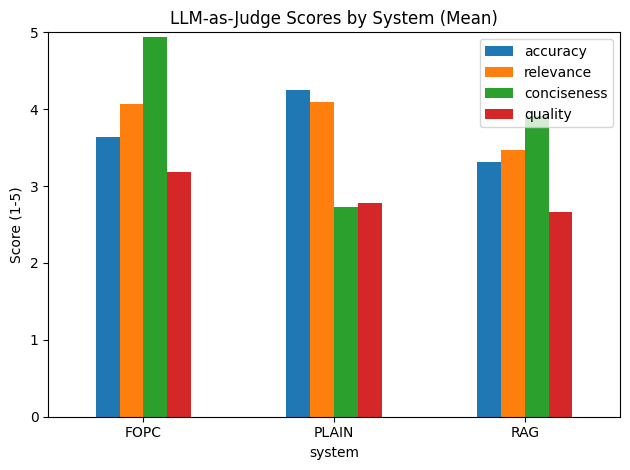

In [69]:
import matplotlib.pyplot as plt

mean_scores = df.groupby("system")[["accuracy","relevance","conciseness","quality"]].mean()

ax = mean_scores.plot(kind="bar")
plt.title("LLM-as-Judge Scores by System (Mean)")
plt.ylabel("Score (1-5)")
plt.ylim(0, 5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

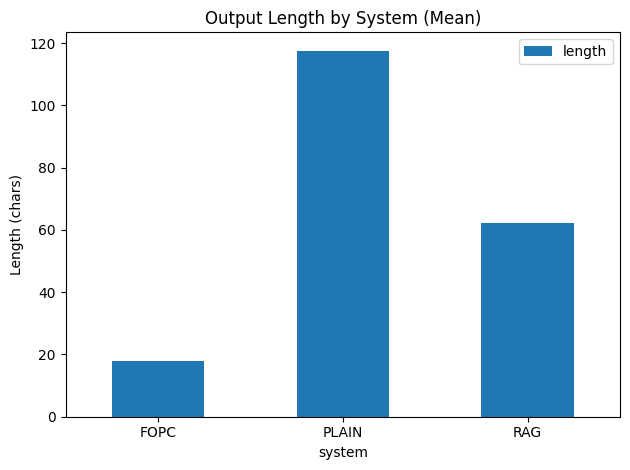

In [70]:
mean_len = df.groupby("system")[["length"]].mean()

ax = mean_len.plot(kind="bar")
plt.title("Output Length by System (Mean)")
plt.ylabel("Length (chars)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

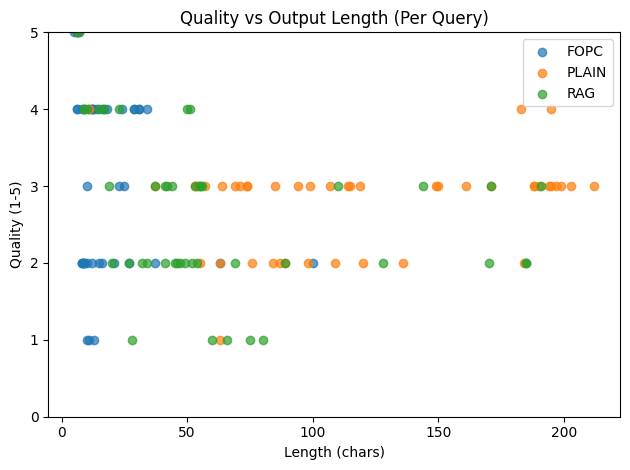

In [71]:
plt.figure()
for system, g in df.groupby("system"):
    plt.scatter(g["length"], g["quality"], label=system, alpha=0.7)

plt.title("Quality vs Output Length (Per Query)")
plt.xlabel("Length (chars)")
plt.ylabel("Quality (1-5)")
plt.ylim(0, 5)
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
df["overall"] = df[["accuracy","relevance","conciseness","quality"]].mean(axis=1)

overall_mean = df.groupby("system")[["overall","length"]].mean().round(3)
print(overall_mean)

        overall   length
system                  
FOPC      3.956   17.911
PLAIN     3.461  117.556
RAG       3.339   62.156


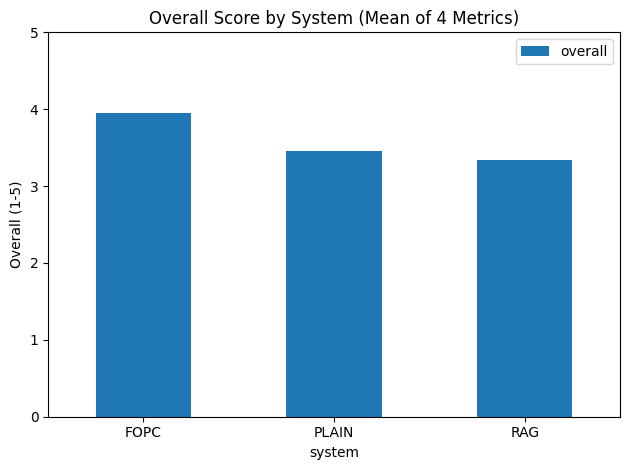

In [73]:
ax = df.groupby("system")[["overall"]].mean().plot(kind="bar")
plt.title("Overall Score by System (Mean of 4 Metrics)")
plt.ylabel("Overall (1-5)")
plt.ylim(0, 5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()